In [29]:
import pandas as pd

# specify encoding to avoid UnicodeDecodeError
# the file contains characters that aren't valid UTF-8

df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [30]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [32]:
print("Number of Rows:", len(df))
print("Number of Unique Customers:", df["Customer ID"].nunique())
print("Total Revenue:", df["Sales"].sum())
print("Date Range:", df["Order Date"].min(), "to", df["Order Date"].max())

Number of Rows: 9994
Number of Unique Customers: 793
Total Revenue: 2297200.8603
Date Range: 1/1/2017 to 9/9/2017


In [33]:
## Data cleaning and Feature Engineering

In [34]:
## Converting dates to datetime format
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [35]:
## Clean Time Features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Day"] = df["Order Date"].dt.day
df["Order Weekday"] = df["Order Date"].dt.day_name()

In [36]:
## Calculate Profit Margin
df["Profit Margin"] = df["Profit"] / df["Sales"]
df["Profit Margin"].describe()

count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [37]:
## Calculate Shipping Time
df["Shipping Time"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Shipping Time"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Time, dtype: float64

In [38]:
df.isnull().sum()
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Day,Profit Margin,Shipping Time
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,15.468481,0.120314,3.958175
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,1.000000,-2.750000,0.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,8.000000,0.075000,3.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,15.000000,0.270000,4.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,23.000000,0.362500,5.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,31.000000,0.500000,7.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,8.748327,0.466754,1.747567


In [39]:
df.to_csv("../data/clean/superstore_sales_cleaned.csv", index=False)

In [40]:
df.dtypes


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Order Year                int32
Order Month               int32
Order Day                 int32
Order Weekday               str
Profit Margin           float64
Shipping Time             int64
dtype: object

In [41]:
df["Profit Margin"].describe()


count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

In [42]:
df["Shipping Time"].describe()

count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Time, dtype: float64

In [43]:
## Business Analysis

In [54]:
## Revenue Over Time (By Order Month)
monthly_sales = df.groupby(["Order Month"])["Sales"].sum()
##monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales

Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64

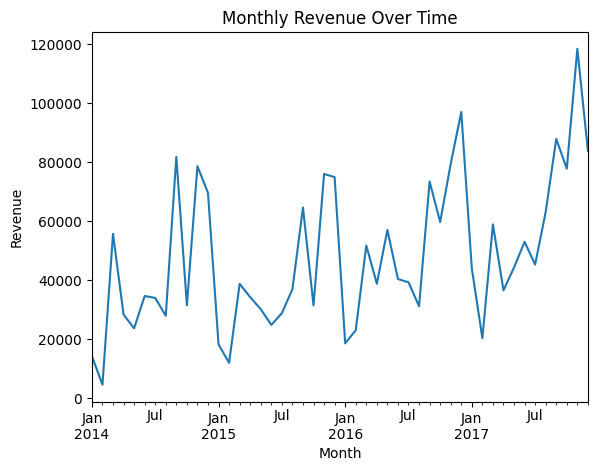

In [45]:
## Plotting Revenue Over Time
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line")
plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [46]:
## Revenue by Category
category_sales = df.groupby(["Category"])["Sales"].sum()
category_sales.sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

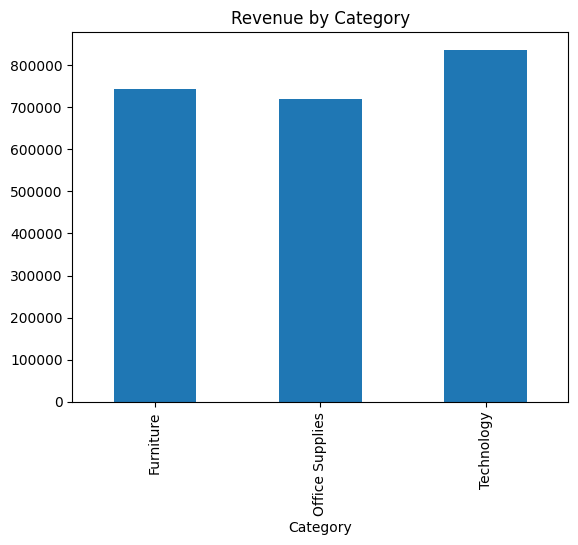

In [47]:
## Plotting Revenue by Category
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

In [48]:
## Profit By Category
category_profit = df.groupby(["Category"])["Profit"].sum()
category_profit.sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

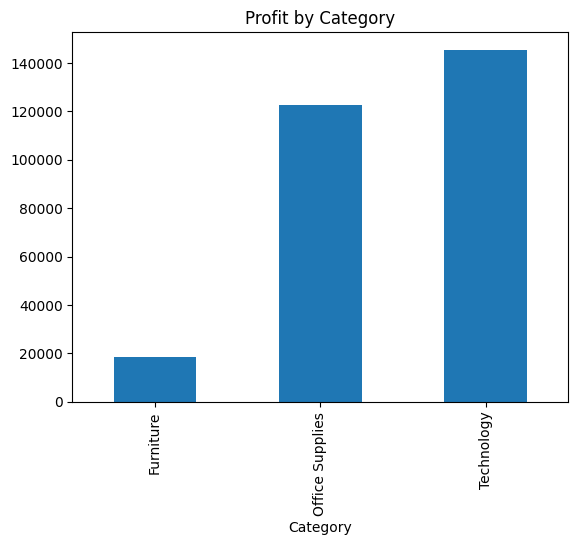

In [49]:
## Plotting Profit by Category
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.show()

In [50]:
## Top customers
top_customers = df.groupby(["Customer Name"])["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

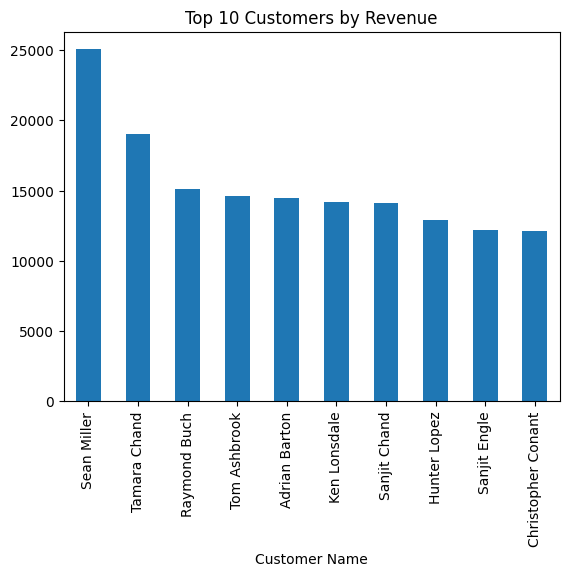

In [51]:
## Plotting Top Customers
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.show()

In [52]:
## Most Profitable Products
top_products = df.groupby(["Product Name"])["Profit"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

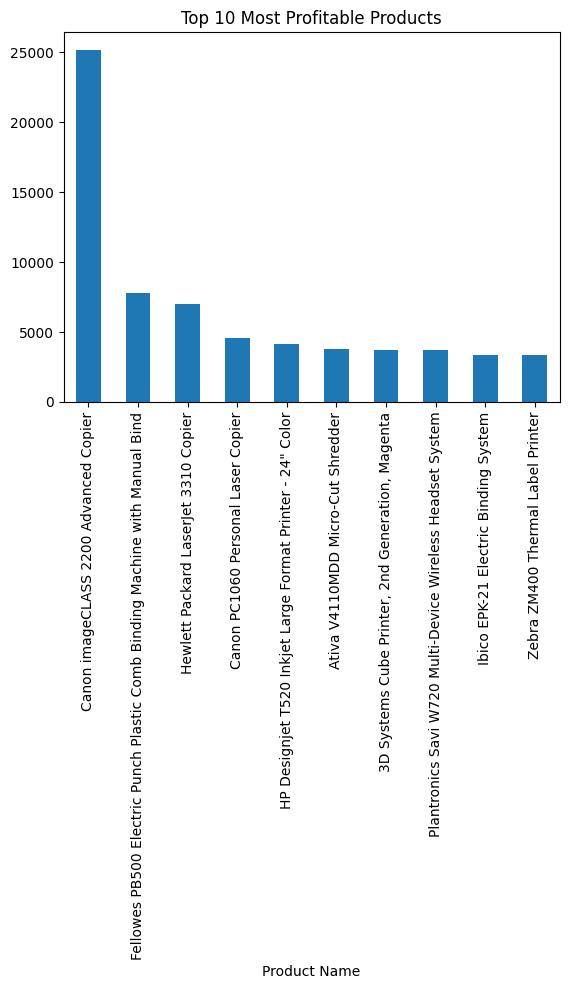

In [53]:
## Plotting Profitable Products
top_products.plot(kind="bar")
plt.title("Top 10 Most Profitable Products")
plt.show()

In [55]:
## Advanced Analysis

In [56]:
## Loss Products
loss_products = df[df["Profit"] < 0].groupby(["Product Name"])["Profit"].sum().sort_values().head(10)
loss_products

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64

In [57]:
## Discount vs. Profit
discount_profit = df.groupby(["Discount"])["Profit"].mean()
discount_profit

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

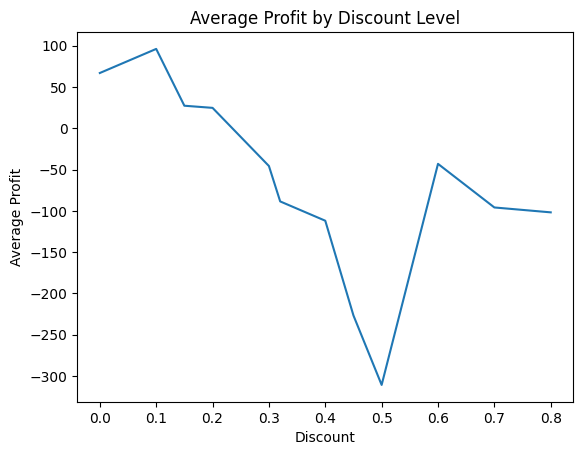

In [59]:
## Plotting Discount vs. Profit
discount_profit.plot(kind="line")
plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

In [62]:
## Regional Performance (Sales by Region)
region_sales = df.groupby(["Region"])["Sales"].sum()
region_sales.sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [63]:
## Regional Performance (Profit by Region)
region_profit = df.groupby(["Region"])["Profit"].sum()
region_profit.sort_values(ascending=False)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [ ]:
## Identifying Loss-Making Orders
loss_orders = df[df["Profit"] < 0]

loss_orders_pct = loss_orders["Sales"].sum() / df["Sales"].sum() * 100
"${:,.2f}".format(loss_orders["Sales"].sum())


'$468,707.15'

In [ ]:
## Loss-Making Orders Percentage
"{:.2f}%".format(loss_orders_pct)

'20.40%'

In [ ]:
## Loss-Making Oder Numbers
len(loss_orders)

1871

In [84]:
## Discount by Category
df.groupby(["Category"])["Discount"].mean().sort_values(ascending=False)

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [85]:
## Profit by Category
df.groupby(["Category"])["Profit Margin"].sum().sort_values(ascending=False)

Category
Office Supplies    831.770556
Technology         288.386984
Furniture           82.259874
Name: Profit Margin, dtype: float64

In [88]:
## Loss by Category
loss_by_category = (df.groupby("Category")["Profit"].sum() / df.groupby("Category")["Sales"].sum())
loss_by_category

Category
Furniture          0.024867
Office Supplies    0.170352
Technology         0.173957
dtype: float64